# KIT Automotive OBD-II Cleaning Pipeline

This notebook runs the split cleaning workflow:

1. `data_cleaning.py` writes `cleaned_dataset.csv` for model input and `cleaning_enriched.csv` as the audit-ready intermediate.
2. `quality_audit.py` reads `cleaning_enriched.csv` and writes `cleaning_quality.csv` plus `cleaning_report.json`.

The cleaned model CSV intentionally keeps only sequence keys and sensor values. Quality flags, lineage columns, and audit details stay in the enriched and quality outputs.


In [10]:
from pathlib import Path
import sys
import pandas as pd

# Find the local cleaning package without hard-coding the repository layout.
path_candidates = [Path.cwd(), *Path.cwd().rglob("project_paths.py")]
for candidate in path_candidates:
    cleaning_dir = candidate if candidate.is_dir() else candidate.parent
    if (cleaning_dir / "project_paths.py").exists():
        sys.path.insert(0, str(cleaning_dir.resolve()))
        break
else:
    raise FileNotFoundError("Could not find project_paths.py from the current workspace.")

from project_paths import (
    CONFIG_PATH,
    CLEANED_DATASET,
    ENRICHED_DATASET,
    QUALITY_CSV,
    REPORT_JSON,
    REPO_ROOT,
)
from cleaning_core import (
    build_output_columns,
    build_quality_output_columns,
    discover_input_files,
    load_config,
)
from data_cleaning import run_cleaning
from quality_audit import run_quality_audit

config = load_config(CONFIG_PATH)

print("Pipeline version:", config["version"])
print("Repository root:", REPO_ROOT)
print("Input directory:", config["input"]["directory"])
print("Cleaned CSV:", CLEANED_DATASET)
print("Enriched CSV:", ENRICHED_DATASET)
print("Quality CSV:", QUALITY_CSV)
print("Report JSON:", REPORT_JSON)


Pipeline version: 3.0
Repository root: C:\Users\Peter\Desktop\Summer Project\granite-lifeline
Input directory: ./data/raw/OBD-II-Dataset
Cleaned CSV: C:\Users\Peter\Desktop\Summer Project\granite-lifeline\data\processed\cleaned_dataset.csv
Enriched CSV: C:\Users\Peter\Desktop\Summer Project\granite-lifeline\data_layer\cleaning_and_profiling\data_cleaning\cleaning_enriched.csv
Quality CSV: C:\Users\Peter\Desktop\Summer Project\granite-lifeline\data_layer\cleaning_and_profiling\data_cleaning\cleaning_quality.csv
Report JSON: C:\Users\Peter\Desktop\Summer Project\granite-lifeline\data_layer\cleaning_and_profiling\data_cleaning\cleaning_report.json


## 1. Input and Schema Check

Confirm the raw input files and the expected output schemas before running the full cleaning step.


In [11]:
input_files = discover_input_files(config, REPO_ROOT)
print(f"CSV files: {len(input_files)}")
print("First file:", input_files[0].name if input_files else "None")
print("Model columns:", len(build_output_columns(config)))
print(build_output_columns(config))
print("Quality columns:", len(build_quality_output_columns(config)))


CSV files: 81
First file: 2017-07-05_Seat_Leon_RT_S_Stau.csv
Model columns: 14
['timestamp', 'trip_id', 'segment_id', 'row_in_segment', 'coolant_temp', 'map', 'rpm', 'speed', 'intake_temp', 'maf', 'tps', 'ambient_temp', 'accel_pedal_d', 'accel_pedal_e']
Quality columns: 50


## 2. Run Cleaning

This step runs deterministic cleaning once, writes `cleaned_dataset.csv`, and saves `cleaning_enriched.csv` for the audit step.


In [12]:
cleaned, cleaning_summary = run_cleaning(config)

print(f"Processed files: {cleaning_summary['files_processed']}")
print(f"Input rows:      {cleaning_summary['input_rows']:,}")
print(f"Output rows:     {cleaning_summary['output_rows']:,}")
print(f"Trips:           {cleaning_summary['trips']}")
print(f"Segments:        {cleaning_summary['segments']}")
display(cleaned.head())


Processed files: 81
Input rows:      2,693,824
Output rows:     249,694
Trips:           81
Segments:        118


,timestamp,trip_id,segment_id,row_in_segment,coolant_temp,map,rpm,speed,intake_temp,maf,tps,ambient_temp,accel_pedal_d,accel_pedal_e
0,2017-07-05T05:16:30Z,trip_0001,trip_0001_seg_001,1,31.0,96.0,0.0,0.0,22.0,0.91,89.0,NaN,NaN,NaN
1,2017-07-05T05:16:31Z,trip_0001,trip_0001_seg_001,2,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
2,2017-07-05T05:16:32Z,trip_0001,trip_0001_seg_001,3,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
3,2017-07-05T05:16:33Z,trip_0001,trip_0001_seg_001,4,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5
4,2017-07-05T05:16:34Z,trip_0001,trip_0001_seg_001,5,31.0,96.0,0.0,0.0,22.0,0.91,89.0,21.0,14.1,14.5


## 3. Run Quality Audit

This step reads the enriched intermediate and writes the row-level quality CSV plus the English JSON report.


In [13]:
quality, audit_report = run_quality_audit(config)

print(f"Quality rows: {audit_report['quality_rows']:,}")
print(f"Trips:        {audit_report['trips']}")
print(f"Segments:     {audit_report['segments']}")
display(quality.head())


Quality rows: 249,694
Trips:        81
Segments:     118


,timestamp,trip_id,segment_id,row_in_segment,source_file,brand,model,origin,destination,route,...,accel_pedal_d_is_imputed,accel_pedal_d_is_suspicious,accel_pedal_d_had_hard_invalid_source,accel_pedal_e_is_imputed,accel_pedal_e_is_suspicious,accel_pedal_e_had_hard_invalid_source,is_imputed_any,is_suspicious_any,had_hard_invalid_source_any,quality_flags
0,2017-07-05T05:16:30Z,trip_0001,trip_0001_seg_001,1,2017-07-05_Seat_Leon_RT_S_Stau.csv,Seat,Leon,RT,S,RT_S,...,False,False,False,False,False,False,False,False,False,NaN
1,2017-07-05T05:16:31Z,trip_0001,trip_0001_seg_001,2,2017-07-05_Seat_Leon_RT_S_Stau.csv,Seat,Leon,RT,S,RT_S,...,False,False,False,False,False,False,False,False,False,NaN
2,2017-07-05T05:16:32Z,trip_0001,trip_0001_seg_001,3,2017-07-05_Seat_Leon_RT_S_Stau.csv,Seat,Leon,RT,S,RT_S,...,False,False,False,False,False,False,False,False,False,NaN
3,2017-07-05T05:16:33Z,trip_0001,trip_0001_seg_001,4,2017-07-05_Seat_Leon_RT_S_Stau.csv,Seat,Leon,RT,S,RT_S,...,False,False,False,False,False,False,False,False,False,NaN
4,2017-07-05T05:16:34Z,trip_0001,trip_0001_seg_001,5,2017-07-05_Seat_Leon_RT_S_Stau.csv,Seat,Leon,RT,S,RT_S,...,False,False,False,False,False,False,False,False,False,NaN


## 4. Contract Checks

Validate the composite key, column contracts, and one-second cadence inside each segment.


In [14]:
expected_model_columns = build_output_columns(config)
expected_quality_columns = build_quality_output_columns(config)

assert list(cleaned.columns) == expected_model_columns
assert list(quality.columns) == expected_quality_columns

key_columns = ["trip_id", "segment_id", "timestamp"]
assert not cleaned.duplicated(key_columns).any()
assert not quality.duplicated(key_columns).any()
assert len(cleaned) == len(quality)
assert cleaned[key_columns].equals(quality[key_columns])

timestamps = pd.to_datetime(cleaned["timestamp"], utc=True, errors="raise")
segment_diffs = (
    cleaned.assign(_timestamp=timestamps)
    .groupby("segment_id", sort=False)["_timestamp"]
    .diff()
    .dt.total_seconds()
)
assert segment_diffs.dropna().eq(1).all()
assert cleaned.groupby("segment_id")["row_in_segment"].min().eq(1).all()

print("Composite key, column contract, and 1 Hz segment checks: PASS")


Composite key, column contract, and 1 Hz segment checks: PASS


## 5. Quality Summary

Review remaining missing values and row-level quality flags without mixing audit fields into the model-input CSV.


In [15]:
quality_rows = []
for field, spec in config["fields"].items():
    non_missing = cleaned[field].dropna()
    quality_rows.append({
        "field": field,
        "unit": spec["unit"],
        "min": non_missing.min() if len(non_missing) else None,
        "max": non_missing.max() if len(non_missing) else None,
        "imputed_values": int(quality[f"{field}_is_imputed"].sum()),
        "suspicious_values": int(quality[f"{field}_is_suspicious"].sum()),
        "hard_invalid_source_bins": int(
            quality[f"{field}_had_hard_invalid_source"].sum()
        ),
        "remaining_missing": int(cleaned[field].isna().sum()),
    })

quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)
print("Rows with any imputation:", int(quality["is_imputed_any"].sum()))
print("Rows with any suspicious value:", int(quality["is_suspicious_any"].sum()))
print("Rows with hard-invalid source values:", int(quality["had_hard_invalid_source_any"].sum()))


,field,unit,min,max,imputed_values,suspicious_values,hard_invalid_source_bins,remaining_missing
0,coolant_temp,°C,-1.0,103.00,56,0,0,1
1,map,kPa,36.0,247.00,56,0,0,3
2,rpm,rpm,0.0,4315.00,56,0,0,7
3,speed,km/h,0.0,218.00,56,0,0,12
4,intake_temp,°C,-40.0,150.00,56,3470,0,19
5,maf,g/s,0.0,129.22,56,0,0,24
6,tps,%,13.7,89.00,56,0,0,32
7,ambient_temp,°C,-14.0,33.00,0,0,0,94
8,accel_pedal_d,%,14.1,85.10,56,0,0,50
9,accel_pedal_e,%,14.1,84.30,56,0,0,60


Rows with any imputation: 56
Rows with any suspicious value: 3470
Rows with hard-invalid source values: 0


## 6. Visual Checks

Use plots to inspect one representative segment and to summarize row-level quality flags. These charts are for human review only; they do not change any output files.


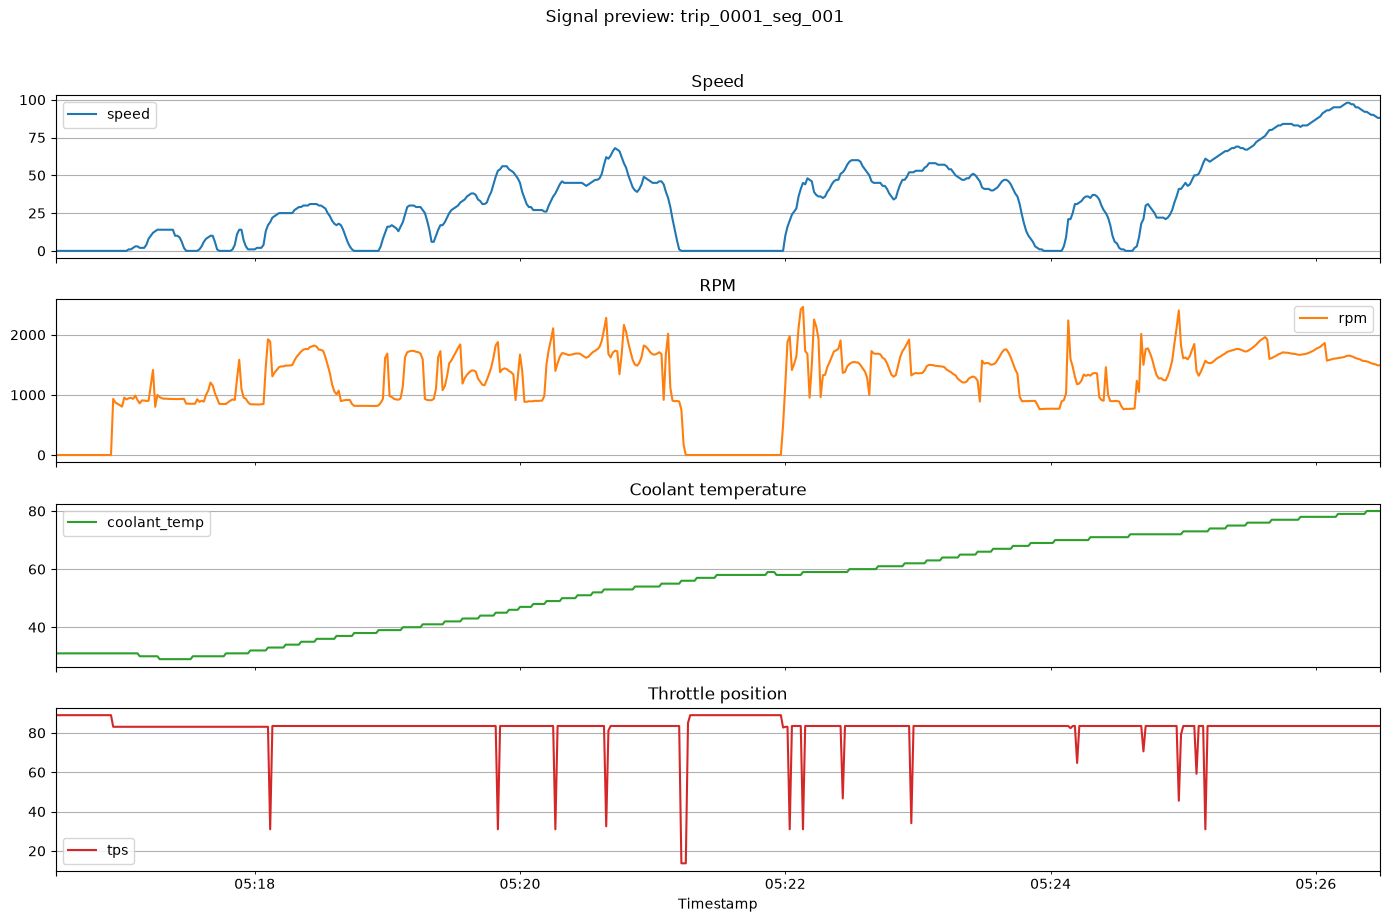

In [16]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "cleaned" not in globals():
        cleaned = pd.read_csv(CLEANED_DATASET)

    preview_segment = cleaned["segment_id"].iloc[0]
    preview = cleaned.loc[cleaned["segment_id"].eq(preview_segment)].head(600).copy()
    preview["timestamp"] = pd.to_datetime(preview["timestamp"], utc=True)
    preview = preview.set_index("timestamp")

    signal_columns = ["speed", "rpm", "coolant_temp", "tps"]
    axes = preview[signal_columns].plot(
        subplots=True,
        figsize=(14, 9),
        title=["Speed", "RPM", "Coolant temperature", "Throttle position"],
        grid=True,
    )
    for axis in axes:
        axis.set_xlabel("Timestamp")
    plt.suptitle(f"Signal preview: {preview_segment}", y=1.02)
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; signal preview skipped.")
except FileNotFoundError as exc:
    print(f"Required CSV file is missing: {exc.filename}. Run the cleaning cells first.")


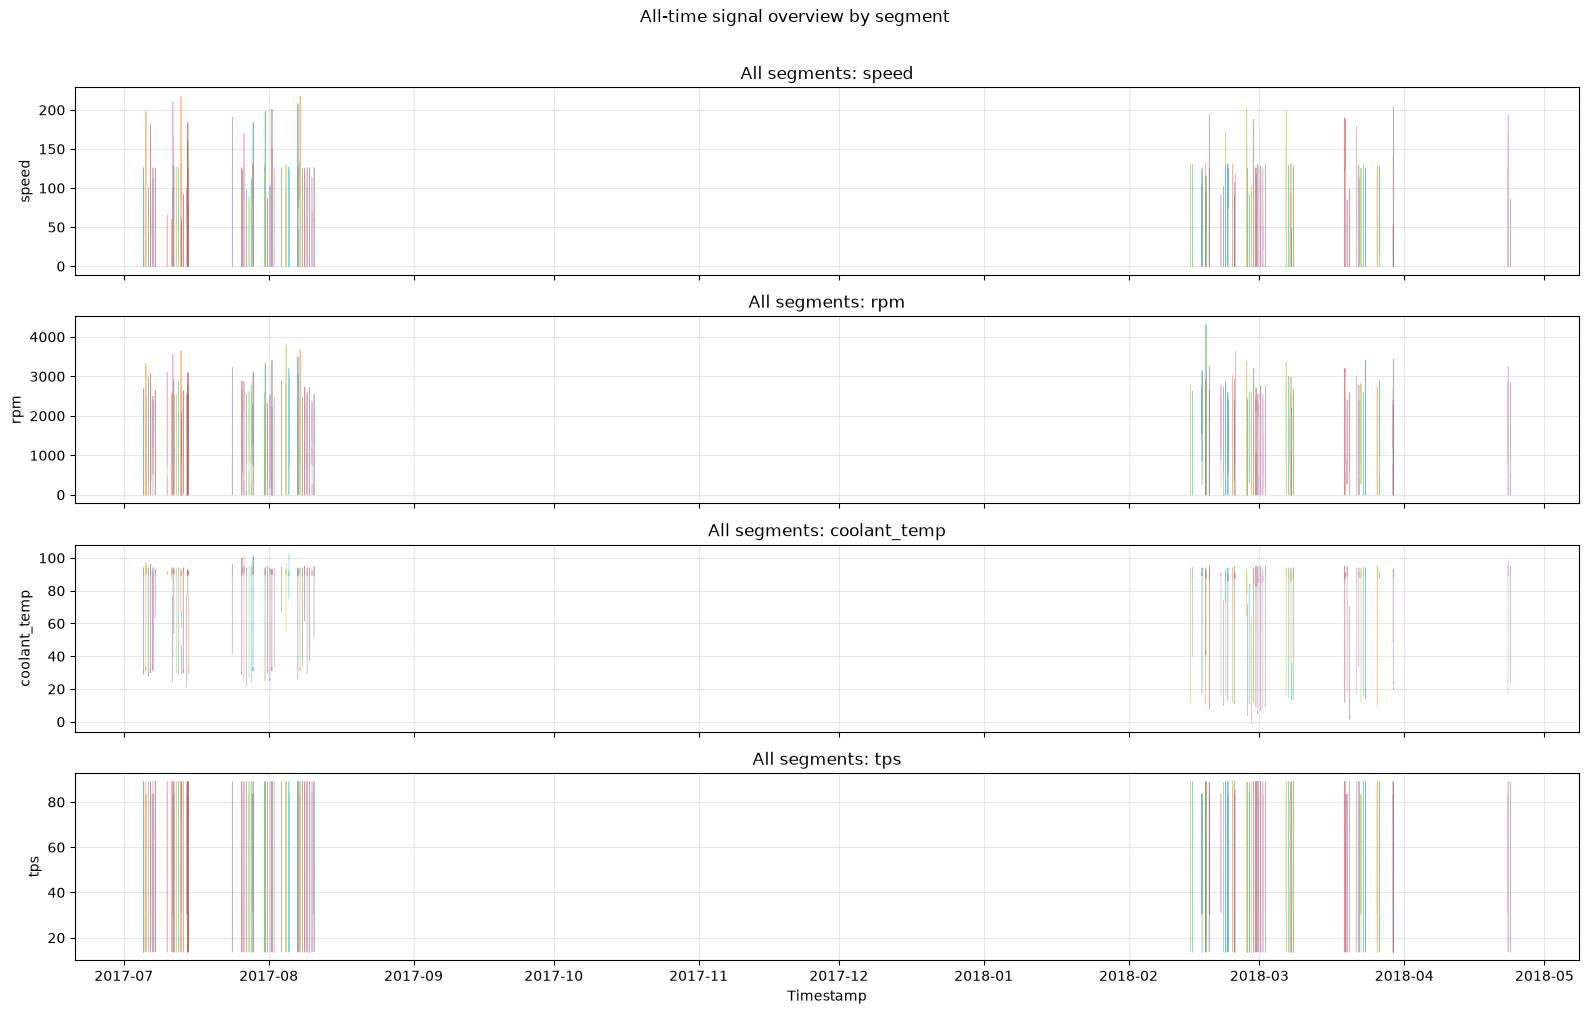

In [17]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "cleaned" not in globals():
        cleaned = pd.read_csv(CLEANED_DATASET)

    overview = cleaned.copy()
    overview["timestamp"] = pd.to_datetime(overview["timestamp"], utc=True)
    signal_columns = ["speed", "rpm", "coolant_temp", "tps"]

    fig, axes = plt.subplots(
        len(signal_columns),
        1,
        figsize=(16, 10),
        sharex=True,
    )

    # Plot each segment separately so gaps between trips are not connected.
    for axis, column in zip(axes, signal_columns):
        for _, segment in overview.groupby("segment_id", sort=False):
            axis.plot(
                segment["timestamp"],
                segment[column],
                linewidth=0.55,
                alpha=0.55,
            )
        axis.set_title(f"All segments: {column}")
        axis.set_ylabel(column)
        axis.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Timestamp")
    plt.suptitle("All-time signal overview by segment", y=1.01)
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; all-time overview skipped.")
except FileNotFoundError as exc:
    print(f"Required CSV file is missing: {exc.filename}. Run the cleaning cells first.")


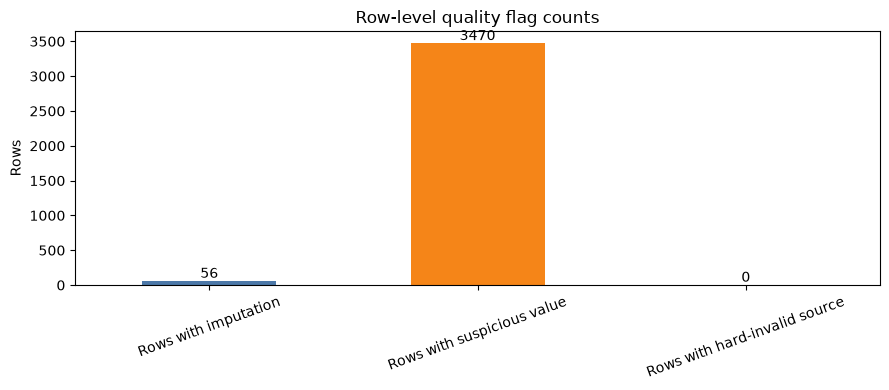

In [18]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt

    if "quality" not in globals():
        quality = pd.read_csv(QUALITY_CSV, low_memory=False)

    quality_counts = pd.Series({
        "Rows with imputation": int(quality["is_imputed_any"].sum()),
        "Rows with suspicious value": int(quality["is_suspicious_any"].sum()),
        "Rows with hard-invalid source": int(
            quality["had_hard_invalid_source_any"].sum()
        ),
    })

    ax = quality_counts.plot(kind="bar", figsize=(9, 4), color=["#4C78A8", "#F58518", "#E45756"])
    ax.set_title("Row-level quality flag counts")
    ax.set_ylabel("Rows")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.bar_label(ax.containers[0], fmt="%.0f")
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Matplotlib is not installed; quality chart skipped.")
except FileNotFoundError as exc:
    print(f"Required CSV file is missing: {exc.filename}. Run the cleaning and audit cells first.")
